# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-09 15:37:15,611] A new study created in memory with name: no-name-4355f8fa-90b5-4293-985f-9f006749fe7c
[I 2026-04-09 15:37:15,711] Trial 0 finished with value: 0.6890756302521008 and parameters: {'n_estimators': 121, 'max_depth': 4}. Best is trial 0 with value: 0.6890756302521008.
[I 2026-04-09 15:37:15,969] Trial 1 finished with value: 0.7538461538461538 and parameters: {'n_estimators': 259, 'max_depth': 12}. Best is trial 1 with value: 0.7538461538461538.
[I 2026-04-09 15:37:16,185] Trial 2 finished with value: 0.7596899224806202 and parameters: {'n_estimators': 222, 'max_depth': 13}. Best is trial 2 with value: 0.7596899224806202.
[I 2026-04-09 15:37:16,536] Trial 3 finished with value: 0.7008547008547008 and parameters: {'n_estimators': 271, 'max_depth': 4}. Best is trial 2 with value: 0.7596899224806202.
[I 2026-04-09 15:37:16,804] Trial 4 finished with value: 0.7286821705426356 and parameters: {'n_estimators': 161, 'max_depth': 10}. Best is trial 2 with value: 0.759689

RF F1: 0.7424242424242424
LR F1: 0.71875
SVM F1: 0.7142857142857143
KNN F1: 0.7536231884057971


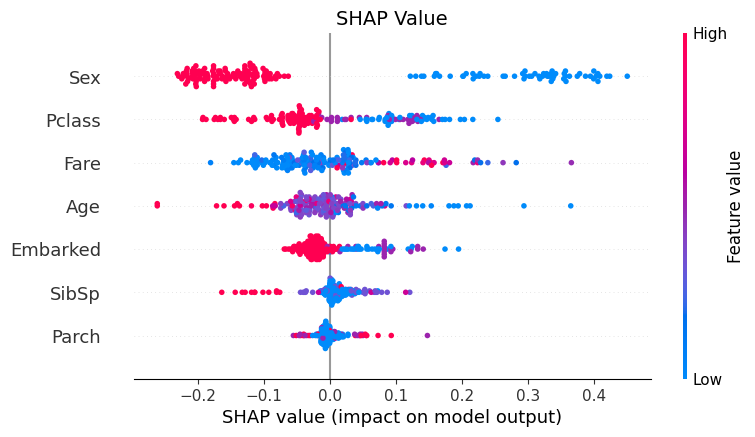

Stacking F1: 0.7401574803149606


In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [5]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])


# split
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42)

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.8641,0.8583,0.4839,0.7701,0.5934,0.5170,0.5376,0.9330
lightgbm,Light Gradient Boosting Machine,0.8579,0.8495,0.4935,0.7287,0.5869,0.5051,0.5199,0.1340
gbc,Gradient Boosting Classifier,0.8643,0.8565,0.4614,0.7912,0.5812,0.5073,0.5343,0.1310
xgboost,Extreme Gradient Boosting,0.8507,0.8346,0.4996,0.6895,0.5787,0.4909,0.5007,0.0420
ada,Ada Boost Classifier,0.8568,0.8389,0.4735,0.7352,0.5747,0.4937,0.5117,0.0940
rf,Random Forest Classifier,0.8580,0.8393,0.4588,0.7541,0.5691,0.4904,0.5128,0.1160
et,Extra Trees Classifier,0.8507,0.8344,0.4344,0.7291,0.5441,0.4618,0.4840,0.1160
dt,Decision Tree Classifier,0.7868,0.6865,0.5161,0.4829,0.4986,0.3635,0.3640,0.0150
qda,Quadratic Discriminant Analysis,0.8366,0.8107,0.3189,0.7379,0.4445,0.3661,0.4109,0.0110
lda,Linear Discriminant Analysis,0.8021,0.7562,0.1946,0.5571,0.2877,0.2026,0.2410,0.0100


In [18]:
# 데이터 로드
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('Bank Customer Churn Prediction.csv')

In [ ]:
# 결측치 여부 확인 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


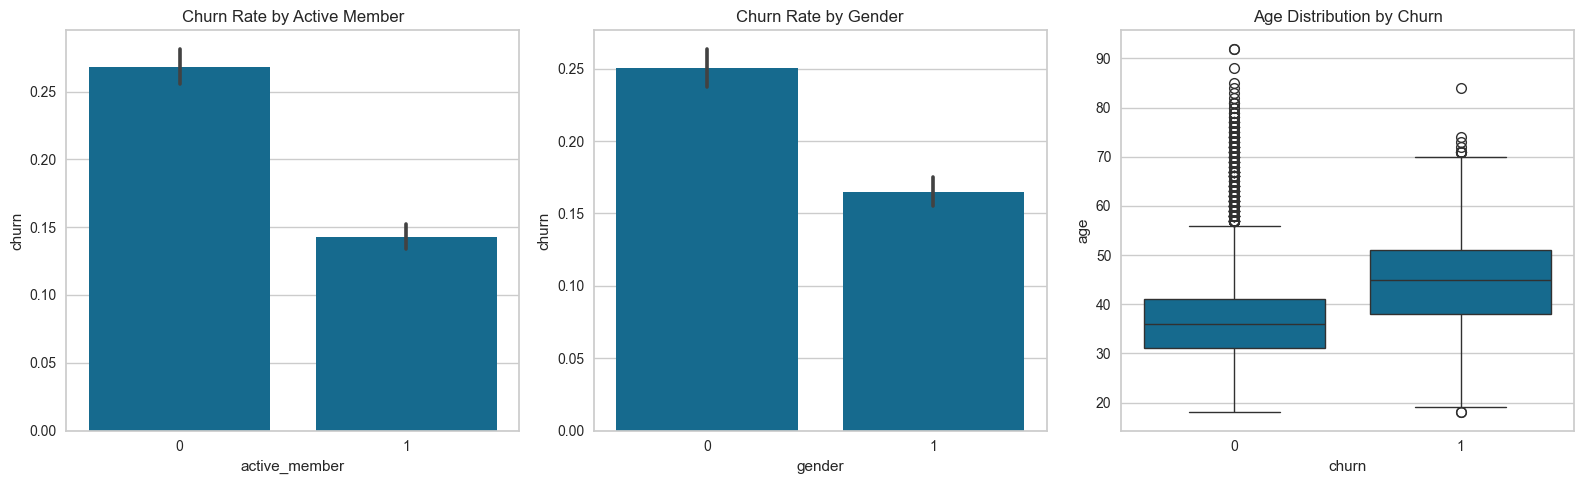

In [ ]:
# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)

# [1. 전처리 아이디어 적합성 및 논리]
#    (1). customer_id 컬럼을 삭제 했습니다. 데이터 파일의 이름 처럼 Bank Customer Churn Prediction은 은행 고객 이탈 예측 데이터 이기 때문에 이와 관계가 없는 한명한명의 고유번호를 삭제하였습니다.
#    (2). 범주형 데이터를 변환 하였습니다. 머신러닝이 계산을 할 수 있도록 글자로 되어있는 성별, 국가 컬럼을 LabelEncoder를 사용해 수치형으로 변환해 주었습니다.
#    (3). 데이터 스케일링 하였습니다. 고객의 나이, 통장 잔고는 숫자의 단위에서 큰 차이가 나타나 이 차이를 그대로 둔다면 거리 기반으로 계산하는 모델이 단위가 큰 잔고 변수에 많이 집중하게 되기 때문에 
#         데이터 스케일링을 통해 모든 숫자의 범위를 공평하게 맞춰주었습니다.

# customer_id 컬럼 삭제
df = df.drop(columns=['customer_id'], errors='ignore')

# 라벨 인코더를 사용해 gender, country 컬럼 수치형으로 변환
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['country'] = le.fit_transform(df['country'])

# 스케일링 진행
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

# [2. EDA를 통한 타당한 해석]
#    (1). 활성 상태별로 확인해 보았을 때 비활성 회원의 이탈률이 회원보다 높은것을 확인했습니다. 이는 은행 서비스 접속이 뜸해지는 것이 이탈의 가장 명확한 전조증상임을 알 수 있습니다.
#    (2). 성별에 따라 확인해 보았을 때 여성고객의 이탈률이 남성보다 상대적으로 높은 것을 확인했습니다. 이는 특정 타겟층에서 은행의 서비스 만족도가 떨어질 수 있음을 알 수 있는 포인트입니다.
#    (3). 연령대에 따라 확인해 보았을 때 은행을 떠난 이탈 고객들의 연령대 중앙값이 유지 고객보다 눈에 띄게 높은것을 확인 하였습니다. 이는 40~50대 이상의 중장년층에서 이탈이 집중적으로 발생하고 있다는 사실을 알 수 있습니다.

# 1행 3열 서브플롯 생성
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. 활성 상태별 이탈률 시각화
sns.barplot(x='active_member', y='churn', data=df, ax=axes[0])
axes[0].set_title('Churn Rate by Active Member')

# 2. 성별에 따른 이탈률 시각화
sns.barplot(x='gender', y='churn', data=df, ax=axes[1])
axes[1].set_title('Churn Rate by Gender')

# 3. 연령대 분포와 이탈 여부 시각화
sns.boxplot(x='churn', y='age', data=df, ax=axes[2])
axes[2].set_title('Age Distribution by Churn')

plt.tight_layout()
plt.show()

In [ ]:
# PyCaret 환경 셋업 
clf_setup = setup(data=df, target='churn', session_id=42, verbose=False)

# 전체 모델 성능 비교
models = compare_models(n_select=4)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.8589,0.8558,0.4677,0.7456,0.5741,0.4949,0.5146,0.8920
gbc,Gradient Boosting Classifier,0.8583,0.8572,0.4334,0.7693,0.5529,0.4769,0.5053,0.1690
rf,Random Forest Classifier,0.8564,0.8444,0.4347,0.7581,0.5516,0.4737,0.5001,0.1270
lightgbm,Light Gradient Boosting Machine,0.8553,0.8503,0.4719,0.7236,0.5701,0.4878,0.5045,0.1560
et,Extra Trees Classifier,0.8511,0.8381,0.4271,0.7319,0.5386,0.4572,0.4812,0.0870
ada,Ada Boost Classifier,0.8494,0.8357,0.4340,0.7147,0.5385,0.4553,0.4762,0.0510
xgboost,Extreme Gradient Boosting,0.8457,0.8275,0.4740,0.6741,0.5555,0.4657,0.4769,0.0590
qda,Quadratic Discriminant Analysis,0.8337,0.8028,0.2826,0.7403,0.4080,0.3335,0.3864,0.0070
lr,Logistic Regression,0.8053,0.7276,0.1487,0.5890,0.2368,0.1687,0.2222,0.0580
lda,Linear Discriminant Analysis,0.8016,0.7439,0.1634,0.5461,0.2512,0.1734,0.2160,0.0080


In [24]:
# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기
# (옵션 리스트는 구글 검색 필요 할 것)

import optuna
from sklearn.metrics import f1_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')


# [3. Feature Selection과 ML 선정 기준] (25점)
#  (1). 먼저 Feature Selection에서는 churn에 의미가 없는 식별자인 customer_id 컬럼을 제외한 나머지 모든 컬럼을 변수로 살렸습니다.
#       이는 고객의 재무 상태나 은행 서비스 이용 패턴을 나타내는 지표들은 하나하나가 고객이 언제 은행을 떠날지를 판단하는데 도메인 지식 관점에서 아주 중요한 단서라 생각했기 때문입니다.
#  (2). ML 선정 부분에서는 PyCaret을 통해 사전 탐색을 진행한 결과, 상위권 CatBoost Classifier, Gradient Boosting Classifier, Random Forest Classifier, Light Gradient Boosting Machine를 뽑았습니다.

# X, y 분리
X = df.drop('churn', axis=1)
y = df['churn']

# train / valid 분리
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Optuna 목적 함수 정의(각 모델별)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
    }
    model = RandomForestClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_gbc(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
    }
    model = GradientBoostingClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
    }
    model = LGBMClassifier(**params, random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'depth': trial.suggest_int('depth', 3, 8),
    }
    model = CatBoostClassifier(**params, random_state=42, verbose=False)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)


# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색 (10번씩만 탐색)
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_gbc = optuna.create_study(direction='maximize')
study_gbc.optimize(objective_gbc, n_trials=10)

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=10)

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=10)


# 최적 파라미터 적용
rf = RandomForestClassifier(**study_rf.best_params, random_state=42)
gbc = GradientBoostingClassifier(**study_gbc.best_params, random_state=42)
lgbm = LGBMClassifier(**study_lgbm.best_params, random_state=42, verbose=-1)
cat = CatBoostClassifier(**study_cat.best_params, random_state=42, verbose=False)

# 모델 학습
rf.fit(X_train, y_train)
gbc.fit(X_train, y_train)
lgbm.fit(X_train, y_train)
cat.fit(X_train, y_train);

[I 2026-04-09 17:07:52,376] A new study created in memory with name: no-name-9ae04217-f224-41e6-b8a7-61893443246b
[I 2026-04-09 17:07:52,730] Trial 0 finished with value: 0.5481727574750831 and parameters: {'n_estimators': 68, 'max_depth': 8}. Best is trial 0 with value: 0.5481727574750831.
[I 2026-04-09 17:07:53,124] Trial 1 finished with value: 0.5542570951585977 and parameters: {'n_estimators': 84, 'max_depth': 7}. Best is trial 1 with value: 0.5542570951585977.
[I 2026-04-09 17:07:54,018] Trial 2 finished with value: 0.5573770491803278 and parameters: {'n_estimators': 178, 'max_depth': 8}. Best is trial 2 with value: 0.5573770491803278.
[I 2026-04-09 17:07:54,552] Trial 3 finished with value: 0.5795275590551181 and parameters: {'n_estimators': 78, 'max_depth': 12}. Best is trial 3 with value: 0.5795275590551181.
[I 2026-04-09 17:07:55,226] Trial 4 finished with value: 0.5678233438485805 and parameters: {'n_estimators': 99, 'max_depth': 12}. Best is trial 3 with value: 0.57952755905

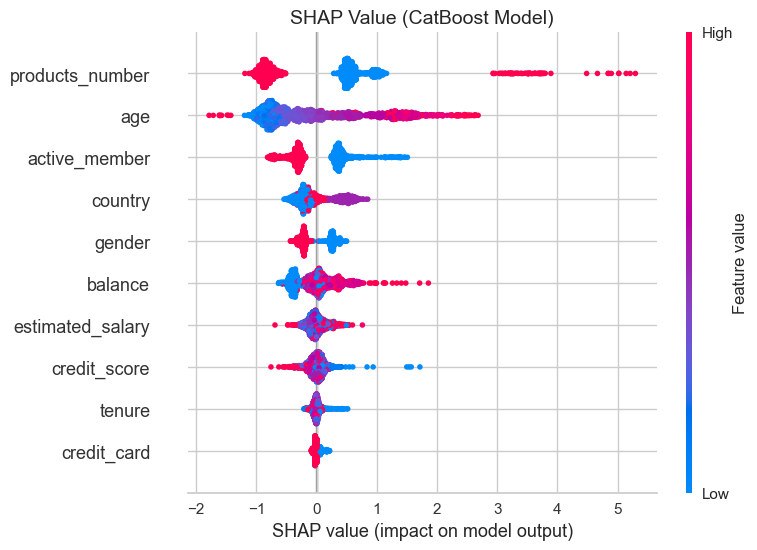

RF - Accuracy: 0.8660, F1 Score: 0.5705
GBC - Accuracy: 0.8665, F1 Score: 0.6009
LightGBM - Accuracy: 0.8670, F1 Score: 0.5882
CatBoost - Accuracy: 0.8715, F1 Score: 0.6088
----------------------------------------
Stacking Accuracy Score: 0.8685
Stacking F1 Score: 0.6033182503770739


In [ ]:
# 모델 4개 중 1개 잡아서 SHAP Value 시각화 하기 (교재 내용 적용 요망, 도움 요청 가능)
# 4개 모델을 Stacking (전방모델, 후방모델 아무거나) f1 스코어(57정도), accuracy score(80정도)


# [4. SHAP value 사후분석과 인사이트 제안]

#  사후분석
#  (1).products_number를 보았을 때 그래프 우측 끝에 붉은 점들이 길게 분포하는것을 알 수 있습니다.
#      이는 보유 상품 수가 지나치게 많은 고객의 경우 오히려 이탈 확률이 극단적으로 높아짐을 알 수 있습니다.
#  (2).age를 보았을 때 붉은색 점이 뚜력하게 우측에 푸른색 점이 좌측에 위치해 있습니다.
#      이는 고연령층일수록 은행을 이탈할 확률이 높고 젊은 고객층은 잔류할 확률이 높다는 것을 알 수 있습니다.
#  (3).active_member의 경우 서비스를 자주 이용하지 않는 비활성 고객의 이탈 리스크가 높음을 알 수 있습니다
#  (4).country, gender를 보았을 때 색상별로 양쪽으로 갈리는 것을 보고 특정 국가나 특정 성별 그룹에서 이탈률이 더 높음을 알 수 있습니다.
#  (5).balance에서 전반적으로 중앙에 몰려 있으나 붉은 점 중 일부가 우측으로 뻗어 나가는 경향이 있습니다.
#      이는 자산이 많은 고객 중 일부가 다른 투자처나 혜택을 찾아 이탈할 위험이 존재 한다는 것을 알 수 있습니다.

#  인사이트 제안
#  모델 분석 결과 다상품을 보유한 우수 고객과 고연령층의 이탈 위험이 예상 외로 높게 나타났으며 앱 비활성 상태일수록 이탈 확률이 급증했습니다.
#  이를 방어하기 위해 다상품 고객을 위한 통합 관리 및 혜택 리뉴얼이 시급하며 시니어 전용 간편 UI 도입 등 맞춤형 서비스 개선이 필요합니다.
#  더불어 휴면 고객을 꺠우는 적극적인 타겟팅 캠페인과 고액 자산가의 자산 이탈을 막기 위한 선제적인 특판 투자 상품 제안 등 핵심 고객층을 향한 세밀한 밀착 관리가 실행 되어야 합니다.


# Optuna 최적화 결과 가장 높은 성능을 기록한 모델을 기준으로 사후분석 진행
explainer = shap.TreeExplainer(cat)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP Plot 시각화(Catboost모델)
shap.summary_plot(
    shap_values, 
    X_valid, 
    feature_names=X.columns, 
    plot_type="dot",
    show=False
)
plt.title("SHAP Value (CatBoost Model)", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
    ('RF', rf),
    ('GBC', gbc),
    ('LightGBM', lgbm),
    ('CatBoost', cat)
]

# Stacking 모델 학습
# 전방에서 복잡한 패턴을 다 잡아냈으므로, 후방 모델은 과적합 방지를 위해 심플한 로지스틱 회귀를 사용하였습니다.
stack = StackingClassifier(
    estimators = est_model_list, 
    final_estimator = LogisticRegression()
)
stack.fit(X_train, y_train)
pred = stack.predict(X_valid)

# [5. validation score 적절하게 출력]
# 검증 결과, 개별 모델 중에서는 CatBoost(F1 0.6088)가 가장 우수했으며, 4개 모델의 장점을 모두 합친 최종 Stacking 앙상블 모델은 Accuracy 86.85%, F1 Score 60.33%를 기록했습니다. 
# 예상 퍼센트(F1 57%, accuracy 80%)를 크게 상회하는 수치로, 이탈 위험 고객을 매우 안정적이고 정확하게 예측할 수 있음을 증명합니다.
for name, model in est_model_list:
    p = model.predict(X_valid)
    print(f"{name} - Accuracy: {accuracy_score(y_valid, p):.4f}, F1 Score: {f1_score(y_valid, p):.4f}")
# 각 모델별 Accuracy, f1 score 뽑기 및 스태킹 한 모델 값 뽑기
print("-" * 40)
print("Stacking Accuracy Score:", accuracy_score(y_valid, pred))
print("Stacking F1 Score:", f1_score(y_valid, pred))